# Report turbulence-CTD on 13 Jan 2026

Includes microCTD and CTD profiles at 3 locations (South Basin, Central Constriction, Western Constriction)

In [1]:
import os
import sys
sys.path.append(os.path.join(os.path.dirname(os.path.abspath("__file__")), r'..\..\..\scripts\functions\figures'))
from functions_figures import array_bands, get_cmap_discrete, compute_logmedian_list
sys.path.append(os.path.join(os.path.dirname(os.path.abspath("__file__")), r'..\..\..\scripts\functions\ctd'))
#from functions_ctd import thorpe_scale
sys.path.append(os.path.join(os.path.dirname(os.path.abspath("__file__")), r'..\..\..\scripts\functions\general_functions'))
from general_functions import read_netCDF_xr, datenum2timestamp
import numpy as np
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import cmocean
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'Arial'  # or any installed font
plt.close('all')


%matplotlib widget 

Parameters

In [2]:
#%% Specify field campaign here:
campaign_name='20260113'
datalevel='Level2'

# Relative path:
data_folder_rel=os.path.join('..','..','..','data','microCTD',campaign_name,datalevel)

#folder_param_name='down1.0_K5.3_L_NAS0.0058_singlepole_nfft3_EPFL_Goodman'
fileprof=['DAT_053_down_prof1','DAT_053_down_prof2','DAT_053_down_prof3',
          'DAT_055_down_prof1','DAT_055_down_prof2','DAT_055_down_prof3',
          'DAT_057_down_prof1','DAT_057_down_prof2','DAT_057_down_prof3',
          'DAT_059_down_prof1','DAT_059_down_prof2'] # all files
profnames=['VMPS','VMPS','VMPS',
           'VMPC1','VMPC1','VMPC1',
           'VMPW','VMPW','VMPW',
           'VMPC2','VMPC2']

indS=np.where(np.array(profnames)=='VMPS')[0]
indC1=np.where(np.array(profnames)=='VMPC1')[0]
indW=np.where(np.array(profnames)=='VMPW')[0]
indC2=np.where(np.array(profnames)=='VMPC2')[0]

# CTD transect:
data_folder_rel_CTD=os.path.join('..','..','..','scripts','data_analysis','2-Process_transect')
fileCTD='CTD_transect_'+campaign_name+'.nc'

savefig=True

colmicro=plt.get_cmap('tab10',len(fileprof))

white_color_fraction=0.6
whitecol=np.array([1,1,1,1])

colC1=[1, 0.4, 0.15]
colC1_light=[1, 0.75, 0.6]
colW=[0.1, 0.6, 0.3]
colW_light=[0.5,0.8,0.5]
colS=[50/255,100/255,214/255]
colS_light=[140/255,170/255,230/255]

Load the data

In [3]:
# Bathymetry:
data_bathy=read_netCDF_xr(os.path.join('..','..','..','data','Bathymetry','Level2','bathymetry_Zug_10m.nc'))

# microCTD profiles:
dataprof=[]
datetime_micro=[]
for kf in range(len(fileprof)):
    if datalevel=='Level1':
        filename_full='L1_'+fileprof[kf]+'.nc'
    elif datalevel=='Level2':
        filename_full='L2_'+fileprof[kf]+'.nc'
    else:
        raise Exception('Wrong level')
        
    dataprof.append(read_netCDF_xr(os.path.join(data_folder_rel,filename_full)))
    datetime_micro.append(pd.to_datetime(datenum2timestamp(dataprof[kf].SLOW_datenum.values[0])+dataprof[kf].SLOW_dtsec.values[0], unit='s'))
    
#%% CTD profiles:
dataprof_CTD=read_netCDF_xr(os.path.join(data_folder_rel_CTD,fileCTD))
#datetime_CTD=dataprof_CTD.time.values.astype('datetime64[s]')
datetime_CTD=pd.to_datetime(dataprof_CTD.time.values, unit='s')

colCTD=get_cmap_discrete('tab10', len(dataprof_CTD.time))
indS_CTD=np.where(dataprof_CTD.profnames.values=='VMPS')[0]
indC_CTD=np.where(dataprof_CTD.profnames.values=='VMPC')[0]
indW_CTD=np.where(dataprof_CTD.profnames.values=='VMPW')[0]


Plot the map

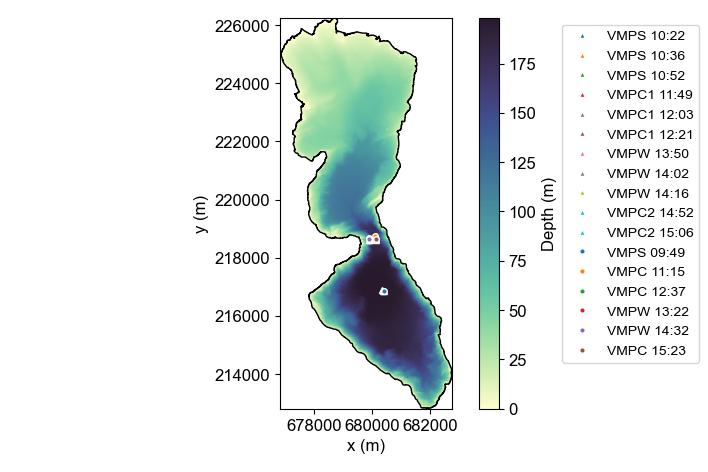

In [4]:
fig,ax = plt.subplots(1,1,figsize=(18 / 2.54, 12 / 2.54))  # Convert from cm to inches

hp=ax.pcolormesh(data_bathy.x-2e6, data_bathy.y-1e6,data_bathy.depth,vmin=0,vmax=np.nanmax(data_bathy.depth),cmap="cmo.deep")
ax.plot(data_bathy.x_contour-2e6, data_bathy.y_contour-1e6, color='k', linewidth=1)
ax.set_aspect("equal")
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
cb = fig.colorbar(hp, ax=ax)
cb.set_label('Depth (m)')

# Add the microCTD profiles:
for kf in range(len(fileprof)):
    if 'x_coord' in dataprof[kf].attrs.keys() and 'y_coord' in dataprof[kf].attrs.keys():
        ax.plot(int(dataprof[kf].x_coord), int(dataprof[kf].y_coord), marker='^', linestyle='', color=colmicro(kf), markersize=4, 
                markeredgecolor='w',markeredgewidth=1,label=profnames[kf]+' '+str(datetime_micro[kf].strftime('%H:%M')))

# Add the CTD profiles:
for kCTD in range(len(dataprof_CTD.time)):
    ax.plot(dataprof_CTD.xcoord[kCTD], dataprof_CTD.ycoord[kCTD], marker='o', linestyle='', color=colCTD(kCTD), markersize=4, 
            markeredgecolor='w',markeredgewidth=1,label=dataprof_CTD.profnames.values[kCTD]+' '+str(datetime_CTD[kCTD].strftime('%H:%M')))
#ax.plot(dataprof_CTD.xcoord[indS_CTD], dataprof_CTD.ycoord[indS_CTD], marker='o', linestyle='', color=colS, markersize=4, markeredgecolor='w',markeredgewidth=1,label='CTD_S')
#ax.plot(dataprof_CTD.xcoord[indC_CTD], dataprof_CTD.ycoord[indC_CTD], marker='o', linestyle='', color=colC1, markersize=4, markeredgecolor='w',markeredgewidth=1,label='CTD_C')
#ax.plot(dataprof_CTD.xcoord[indW_CTD], dataprof_CTD.ycoord[indW_CTD], marker='o', linestyle='', color=colW, markersize=4, markeredgecolor='w',markeredgewidth=1,label='CTD_W')

ax.legend(loc='upper left',bbox_to_anchor=(1.6, 1), fontsize=10)

fig.set_tight_layout(True)

Plot the microCTD profiles

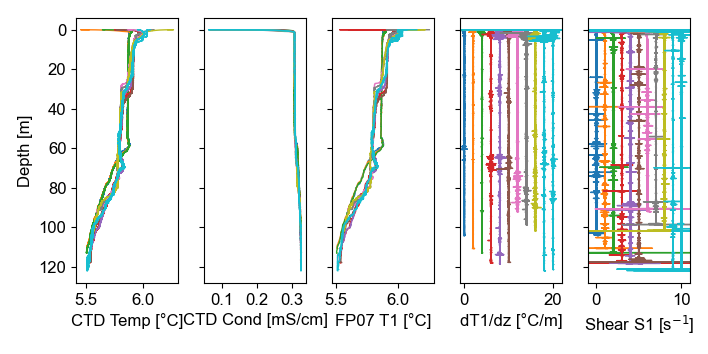

In [12]:

# Create a figure with specified size in centimeters
fig,ax = plt.subplots(1,5,figsize=(18 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches


for kf in range(len(dataprof)):
    ax[0].plot(dataprof[kf].SLOW_temperature.data,dataprof[kf].SLOW_depth,linewidth=1,color=colmicro(kf))
    
    ax[1].plot(dataprof[kf].SLOW_conductivity20.data/1000,dataprof[kf].SLOW_depth,linewidth=1,color=colmicro(kf))
    
    ax[2].plot(dataprof[kf].FAST_fast_T1.data,dataprof[kf].FAST_depth,linewidth=1,color=colmicro(kf))
    
    ax[3].plot(dataprof[kf].FAST_grad_T1.data+2*kf,dataprof[kf].FAST_depth,linewidth=1,color=colmicro(kf))
    
    ax[4].plot(dataprof[kf].FAST_fast_S1.data+kf,dataprof[kf].FAST_depth,linewidth=1,color=colmicro(kf))


# Labels and limits:
ax[0].set_ylabel('Depth [m]')
ax[0].set_xlabel('CTD Temp [°C]')
ax[1].set_xlabel('CTD Cond [mS/cm]')
ax[2].set_xlabel('FP07 T1 [°C]')
ax[3].set_xlabel('dT1/dz [°C/m]')
ax[4].set_xlabel('Shear S1 [s$^{-1}$]')

ax[3].set_xlim(-1,2*len(dataprof))
ax[4].set_xlim(-1,len(dataprof))
ax[0].invert_yaxis()

fig.set_tight_layout(True)

if savefig:
    fig.savefig('comparison_prof_'+campaign_name+'.png',dpi=400)
    #fig.savefig('comparison_prof_'+campaign_name+'.svg',dpi=400)



Plot the turbulence data from the microCTD profiles

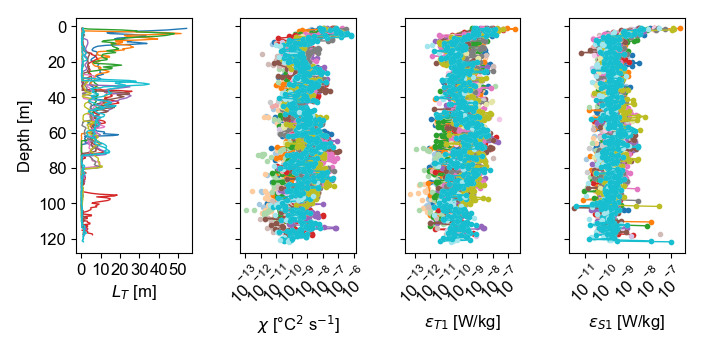

In [6]:

# Create a figure with specified size in centimeters
fig,ax = plt.subplots(1,4,figsize=(18 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches


for kf in range(len(dataprof)):
    pale_color = white_color_fraction * whitecol + (1-white_color_fraction) * np.array(colmicro(kf))
    
    indkeep_T1=np.where(dataprof[kf].BINNED_flag_T1.data==0)[0]
    indkeep_S1=np.where(dataprof[kf].BINNED_flag_S1.data==0)[0]
    
    ax[0].plot(dataprof[kf].BINNED_LTuT1.data,dataprof[kf].BINNED_depth.data,'-',linewidth=1,color=colmicro(kf))
    
    ax[1].plot(dataprof[kf].BINNED_Xi_T1.data,dataprof[kf].BINNED_depth.data,'.',linewidth=1,color=pale_color)
    ax[1].plot(dataprof[kf].BINNED_Xi_T1.data[indkeep_T1],dataprof[kf].BINNED_depth.data[indkeep_T1],'.-',linewidth=1,color=colmicro(kf))
    
    ax[2].plot(dataprof[kf].BINNED_eps_T1.data,dataprof[kf].BINNED_depth.data,'.',linewidth=1,color=pale_color)
    ax[2].plot(dataprof[kf].BINNED_eps_T1.data[indkeep_T1],dataprof[kf].BINNED_depth.data[indkeep_T1],'.-',linewidth=1,color=colmicro(kf))
    
    ax[3].plot(dataprof[kf].BINNED_eps_S1.data,dataprof[kf].BINNED_depth.data,'.',linewidth=1,color=pale_color)
    ax[3].plot(dataprof[kf].BINNED_eps_S1.data[indkeep_S1],dataprof[kf].BINNED_depth.data[indkeep_S1],'.-',linewidth=1,color=colmicro(kf))
    
    
# Labels and limits:
ax[0].set_ylabel('Depth [m]')
ax[0].set_xlabel('$L_T$ [m]')
ax[1].set_xlabel('$\\chi$ [°C$^2$ s$^{-1}$]')
ax[2].set_xlabel('$\\varepsilon_{T1}$ [W/kg]')
ax[3].set_xlabel('$\\varepsilon_{S1}$ [W/kg]')

xlimval=ax[0].get_xlim()
ax[0].set_xticks(np.arange(0, 100, 10))
ax[0].set_xlim(xlimval)

ax[1].set_xscale('log')
xlimval=ax[1].get_xlim()
ax[1].set_xticks(10.0**np.arange(-14, -5, 1))
ax[1].set_xlim(xlimval)
ax[1].tick_params(axis='x', labelrotation=45)

ax[2].set_xscale('log')
xlimval=ax[2].get_xlim()
ax[2].set_xticks(10.0**np.arange(-14, -5, 1))
ax[2].set_xlim(xlimval)
ax[2].tick_params(axis='x', labelrotation=45)

ax[3].set_xscale('log')
xlimval=ax[3].get_xlim()
ax[3].set_xticks(10.0**np.arange(-14, -5, 1))
ax[3].set_xlim(xlimval)
ax[3].tick_params(axis='x', labelrotation=45)

ax[0].invert_yaxis()

fig.set_tight_layout(True)

if savefig:
    fig.savefig('comparison_turbulence_'+campaign_name+'.png',dpi=400)
    #fig.savefig('comparison_turbulence_'+campaign_name+'.svg',dpi=400)



Plot averaged turbulence profiles

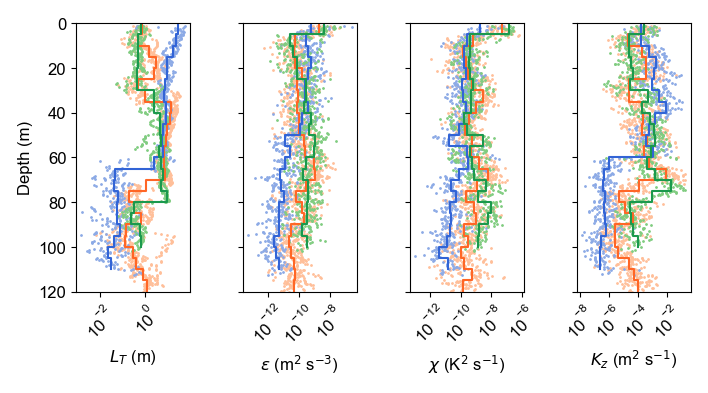

In [7]:


depthmax=120 # [m]
depthcell=5 # [m]

# Create a figure with specified size in centimeters
fig,ax = plt.subplots(1,4,figsize=(18 / 2.54, 10 / 2.54),sharey=True)  # Convert from cm to inches

# 1st subplot: Thorpe-T1
depthS_all, LTS_all, depthS_cells, logmed_LTS = compute_logmedian_list([dataprof[i]["BINNED_depth"].values for i in indS],[dataprof[i]["BINNED_LTuT1"].values for i in indS], depthcell)
# depthC1_all, LTC1_all, depthC1_cells, logmed_LTC1 = compute_logmedian_list([dataprof[i]["BINNED_depth"].values for i in indC1],[dataprof[i]["BINNED_LTuT1"].values for i in indC1], depthcell)
# depthC2_all, LTC2_all, depthC2_cells, logmed_LTC2 = compute_logmedian_list([dataprof[i]["BINNED_depth"].values for i in indC2],[dataprof[i]["BINNED_LTuT1"].values for i in indC2], depthcell)
depthC1_all, LTC1_all, depthC1_cells, logmed_LTC1 = compute_logmedian_list([dataprof[i]["BINNED_depth"].values for i in np.concatenate((indC1,indC2))],[dataprof[i]["BINNED_LTuT1"].values for i in np.concatenate((indC1,indC2))], depthcell)
depthW_all, LTW_all, depthW_cells, logmed_LTW = compute_logmedian_list([dataprof[i]["BINNED_depth"].values for i in indW],[dataprof[i]["BINNED_LTuT1"].values for i in indW], depthcell)


ax[0].plot(LTC1_all, depthC1_all, 'o', markersize=1, markeredgecolor=colC1_light, markerfacecolor=colC1_light,rasterized=True)
ax[0].plot(LTS_all, depthS_all, 'o', markersize=1, markeredgecolor=colS_light, markerfacecolor=colS_light,rasterized=True)
ax[0].plot(LTW_all, depthW_all, 'o', markersize=1, markeredgecolor=colW_light, markerfacecolor=colW_light,rasterized=True)
ax[0].plot(10**logmed_LTC1, depthC1_cells, '-', color=colC1)
ax[0].plot(10**logmed_LTS, depthS_cells, '-',color=colS)
ax[0].plot(10**logmed_LTW, depthW_cells, '-',color=colW)
ax[0].set_ylabel('Depth (m)')
ax[0].set_xlabel(r'$L_{T}$ (m)')
ax[0].set_xscale('log')
xlimval=ax[0].get_xlim()
ax[0].set_xticks(10.0**np.arange(-14, 1, 2))
ax[0].set_xlim(xlimval)
ax[0].tick_params(axis='x', labelrotation=45)

# 2nd subplot: Eps-T1
depthepsS_all, epsS_all, depthS_cells, logmed_epsS = compute_logmedian_list([dataprof[i]["BINNED_depth"].values for i in indS],[dataprof[i]["BINNED_eps_T1"].values for i in indS], depthcell)
# depthC1_all, epsC1_all, depthC1_cells, logmed_epsC1 = compute_logmedian_list([dataprof[i]["BINNED_depth"].values for i in indC1],[dataprof[i]["BINNED_eps_T1"].values for i in indC1], depthcell)
# depthC2_all, epsC2_all, depthC2_cells, logmed_epsC2 = compute_logmedian_list([dataprof[i]["BINNED_depth"].values for i in indC2],[dataprof[i]["BINNED_eps_T1"].values for i in indC2], depthcell)
depthepsC1_all, epsC1_all, depthC1_cells, logmed_epsC1 = compute_logmedian_list([dataprof[i]["BINNED_depth"].values for i in np.concatenate((indC1,indC2))],[dataprof[i]["BINNED_eps_T1"].values for i in np.concatenate((indC1,indC2))], depthcell)
depthepsW_all, epsW_all, depthW_cells, logmed_epsW = compute_logmedian_list([dataprof[i]["BINNED_depth"].values for i in indW],[dataprof[i]["BINNED_eps_T1"].values for i in indW], depthcell)


# Plot the data
ax[1].plot(epsC1_all, depthepsC1_all, 'o', markersize=1, markeredgecolor=colC1_light, markerfacecolor=colC1_light,rasterized=True)
ax[1].plot(epsS_all, depthepsS_all, 'o', markersize=1, markeredgecolor=colS_light, markerfacecolor=colS_light,rasterized=True)
ax[1].plot(epsW_all, depthepsW_all, 'o', markersize=1, markeredgecolor=colW_light, markerfacecolor=colW_light,rasterized=True)
ax[1].plot(10**logmed_epsC1, depthC1_cells, '-', color=colC1)
ax[1].plot(10**logmed_epsS, depthS_cells, '-',color=colS)
ax[1].plot(10**logmed_epsW, depthW_cells, '-',color=colW)

ax[1].set_xlabel(r'$\epsilon$ (m$^2$ s$^{-3}$)')
ax[1].set_xscale('log')
xlimval=ax[1].get_xlim()
ax[1].set_xticks(10.0**np.arange(-14, 1, 2))
ax[1].set_xlim(xlimval)
ax[1].tick_params(axis='x', labelrotation=45)
#ax[1].set_xlim([10**(-11), 10**(-4)])


# 3rd subplot: X-T1
depthXiS_all, XiS_all, depthS_cells, logmed_XiS = compute_logmedian_list([dataprof[i]["BINNED_depth"].values for i in indS],[dataprof[i]["BINNED_Xi_T1"].values for i in indS], depthcell)
# depthC1_all, XiC1_all, depthC1_cells, logmed_XiC1 = compute_logmedian_list([dataprof[i]["BINNED_depth"].values for i in indC1],[dataprof[i]["BINNED_Xi_T1"].values for i in indC1], depthcell)
# depthC2_all, XiC2_all, depthC2_cells, logmed_XiC2 = compute_logmedian_list([dataprof[i]["BINNED_depth"].values for i in indC2],[dataprof[i]["BINNED_Xi_T1"].values for i in indC2], depthcell)
depthXiC1_all, XiC1_all, depthC1_cells, logmed_XiC1 = compute_logmedian_list([dataprof[i]["BINNED_depth"].values for i in np.concatenate((indC1,indC2))],[dataprof[i]["BINNED_Xi_T1"].values for i in np.concatenate((indC1,indC2))], depthcell)
depthXiW_all, XiW_all, depthW_cells, logmed_XiW = compute_logmedian_list([dataprof[i]["BINNED_depth"].values for i in indW],[dataprof[i]["BINNED_Xi_T1"].values for i in indW], depthcell)


ax[2].plot(XiC1_all, depthXiC1_all, 'o', markersize=1, markeredgecolor=colC1_light, markerfacecolor=colC1_light,rasterized=True)
ax[2].plot(XiS_all, depthXiS_all, 'o', markersize=1, markeredgecolor=colS_light, markerfacecolor=colS_light,rasterized=True)
ax[2].plot(XiW_all, depthXiW_all, 'o', markersize=1, markeredgecolor=colW_light, markerfacecolor=colW_light,rasterized=True)
ax[2].plot(10**logmed_XiC1, depthC1_cells, '-', color=colC1)
ax[2].plot(10**logmed_XiS, depthS_cells, '-',color=colS)
ax[2].plot(10**logmed_XiW, depthW_cells, '-',color=colW)
ax[2].set_xlabel(r'$\chi$ (K$^2$ s$^{-1}$)')
ax[2].set_xscale('log')
xlimval=ax[2].get_xlim()
ax[2].set_xticks(10.0**np.arange(-14, 1, 2))
ax[2].set_xlim(xlimval)
ax[2].tick_params(axis='x', labelrotation=45)
#ax[2].set_xlim([10**(-13), 10**(-6)])

# 4th subplot: Kz-T1
depthKzS_all, KzS_all, depthS_cells, logmed_KzS = compute_logmedian_list([dataprof[i]["BINNED_depth"].values for i in indS],[dataprof[i]["BINNED_KOsbornCox_T1"].values for i in indS], depthcell)
# depthC1_all, KzC1_all, depthC1_cells, logmed_KzC1 = compute_logmedian_list([dataprof[i]["BINNED_depth"].values for i in indC1],[dataprof[i]["BINNED_KOsbornCox_T1"].values for i in indC1], depthcell)
# depthC2_all, KzC2_all, depthC2_cells, logmed_KzC2 = compute_logmedian_list([dataprof[i]["BINNED_depth"].values for i in indC2],[dataprof[i]["BINNED_KOsbornCox_T1"].values for i in indC2], depthcell)
depthKzC1_all, KzC1_all, depthC1_cells, logmed_KzC1 = compute_logmedian_list([dataprof[i]["BINNED_depth"].values for i in np.concatenate((indC1,indC2))],[dataprof[i]["BINNED_KOsbornCox_T1"].values for i in np.concatenate((indC1,indC2))], depthcell)
depthKzW_all, KzW_all, depthW_cells, logmed_KzW = compute_logmedian_list([dataprof[i]["BINNED_depth"].values for i in indW],[dataprof[i]["BINNED_KOsbornCox_T1"].values for i in indW], depthcell)


ax[3].plot(KzC1_all, depthKzC1_all, 'o', markersize=1, markeredgecolor=colC1_light, markerfacecolor=colC1_light,rasterized=True)
ax[3].plot(KzS_all, depthKzS_all, 'o', markersize=1, markeredgecolor=colS_light, markerfacecolor=colS_light,rasterized=True)
ax[3].plot(KzW_all, depthKzW_all, 'o', markersize=1, markeredgecolor=colW_light, markerfacecolor=colW_light,rasterized=True)
ax[3].plot(10**logmed_KzC1, depthC1_cells, '-', color=colC1)
ax[3].plot(10**logmed_KzS, depthS_cells, '-',color=colS)
ax[3].plot(10**logmed_KzW, depthW_cells, '-',color=colW)
ax[3].set_xlabel(r'$K_{z}$ (m$^2$ s$^{-1}$)')
ax[3].set_xscale('log')
xlimval=ax[3].get_xlim()
ax[3].set_xticks(10.0**np.arange(-14, 1, 2))
ax[3].set_xlim(xlimval)
ax[3].tick_params(axis='x', labelrotation=45)


ax[0].set_ylim((0,depthmax))
ax[0].invert_yaxis()  # Reverse the y-axis 

fig.set_tight_layout(True)

# Save figure

if savefig:
    fig.savefig('comparison_turbulence_avg_'+campaign_name+'.png',dpi=400)
    #fig.savefig('comparison_turbulence_avg_'+campaign_name+'.svg',dpi=1000)



Plot CTD profiles

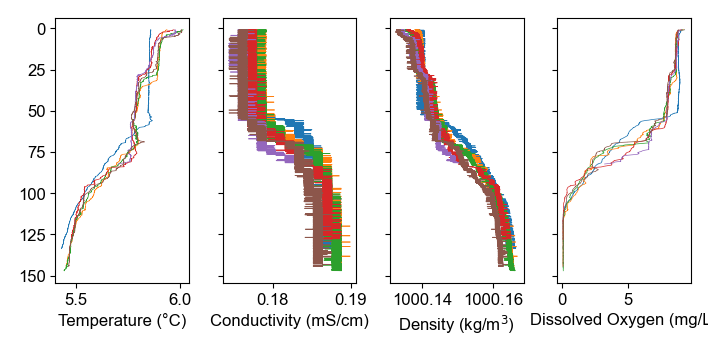

In [11]:

fig,ax = plt.subplots(1,4,figsize=(18 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches

# Plot CTD profiles
for kprof in range(len(dataprof_CTD.time)):
    ax[0].plot(dataprof_CTD["temp"].values[:,kprof], dataprof_CTD["depth"].values, color=colCTD(kprof), linewidth=0.5)
    ax[1].plot(dataprof_CTD["cond"].values[:,kprof], dataprof_CTD["depth"].values, color=colCTD(kprof), linewidth=0.5)
    ax[2].plot(dataprof_CTD["rho"].values[:,kprof], dataprof_CTD["depth"].values, color=colCTD(kprof), linewidth=0.5)
    ax[3].plot(dataprof_CTD["DO"].values[:,kprof], dataprof_CTD["depth"].values, color=colCTD(kprof), linewidth=0.5)
    
ax[0].set_xlabel('Temperature (°C)')
ax[1].set_xlabel('Conductivity (mS/cm)')
ax[2].set_xlabel('Density (kg/m$^3$)')
ax[2].ticklabel_format(useOffset=False, style='plain', axis='x')
ax[3].set_xlabel('Dissolved Oxygen (mg/L)')
ax[0].invert_yaxis()  # Reverse the y-axis 

fig.set_tight_layout(True)

# Save figure

if savefig:
    fig.savefig('CTD_profiles_'+campaign_name+'.png',dpi=400)
    fig.savefig('CTD_profiles_'+campaign_name+'.svg',dpi=1000)

    


Plot temp-DO profiles or density-DO profiles

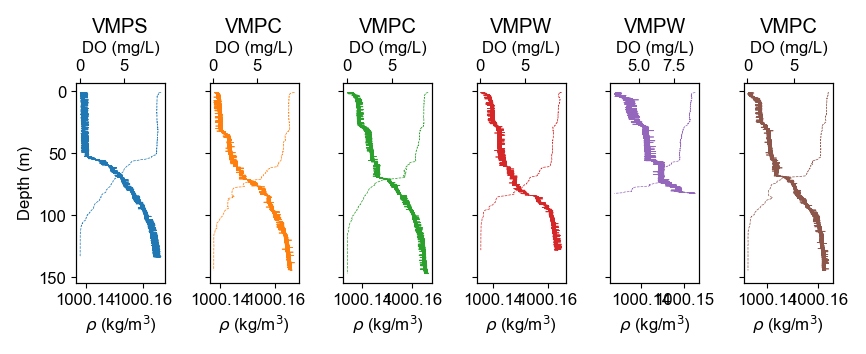

In [9]:

fig,ax = plt.subplots(1,len(dataprof_CTD.time),figsize=(22 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches

# Plot CTD profiles
for kprof in range(len(dataprof_CTD.time)):
    #ax[kprof].plot(dataprof_CTD["temp"].values[:,kprof], dataprof_CTD["depth"].values, color=colCTD(kprof), linewidth=0.5)
    ax[kprof].plot(dataprof_CTD["rho"].values[:,kprof], dataprof_CTD["depth"].values, color=colCTD(kprof), linewidth=0.5)
    ax2=ax[kprof].twiny()
    ax2.plot(dataprof_CTD["DO"].values[:,kprof], dataprof_CTD["depth"].values, '--', color=colCTD(kprof), linewidth=0.5)
    
    #ax[kprof].set_xlabel('T (°C)')
    ax[kprof].set_xlabel('$\\rho$ (kg/m$^3$)')
    ax2.set_xlabel('DO (mg/L)')
    ax[kprof].set_title(dataprof_CTD.profnames.values[kprof])

    ax[kprof].ticklabel_format(useOffset=False, style='plain', axis='x')
ax[0].invert_yaxis()  # Reverse the y-axis
ax[0].set_ylabel('Depth (m)') 

fig.set_tight_layout(True)

# Save figure

if savefig:
    fig.savefig('CTD_profiles_tempDO_'+campaign_name+'.png',dpi=400)
    #fig.savefig('CTD_profiles_tempDO_'+campaign_name+'.svg',dpi=1000)



Plot turbulence and DO on the same figure

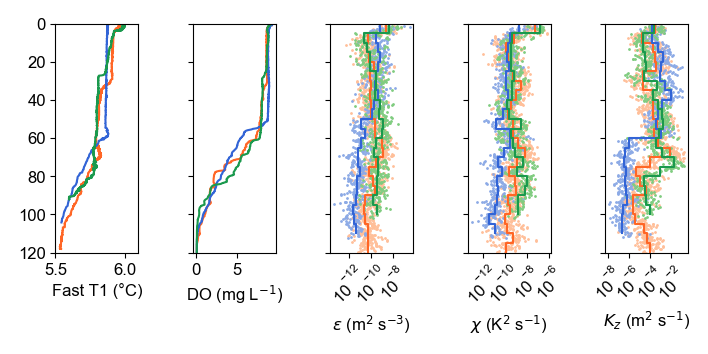

In [10]:
depthmax=120 # [m]

# Create a figure with specified size in centimeters
fig,ax = plt.subplots(1,5,figsize=(18 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches


# 1st plot: fast temperature
ax[0].plot(dataprof[indC1[0]].FAST_fast_T1.data,dataprof[indC1[0]].FAST_depth,linewidth=1.5, color=colC1)
ax[0].plot(dataprof[indS[0]].FAST_fast_T1.data,dataprof[indS[0]].FAST_depth,linewidth=1.5, color=colS)
ax[0].plot(dataprof[indW[0]].FAST_fast_T1.data,dataprof[indW[0]].FAST_depth,linewidth=1.5, color=colW)
ax[0].set_xlim(5.5,6.1)
ax[0].set_xlabel('Fast T1 (°C)')

# 2nd subplot: DO
ax[1].plot(dataprof_CTD.DO.values[:,indC_CTD[0]],dataprof_CTD.depth.values, '-', linewidth=1.5, color=colC1)
ax[1].plot(dataprof_CTD.DO.values[:,indS_CTD[0]],dataprof_CTD.depth.values, '-', linewidth=1.5, color=colS)
ax[1].plot(dataprof_CTD.DO.values[:,indW_CTD[0]],dataprof_CTD.depth.values, '-',linewidth=1.5,  color=colW)
ax[1].set_xlabel('DO (mg L$^{-1}$)')


# 2nd subplot: Eps-T1

ax[2].plot(epsC1_all, depthepsC1_all, 'o', markersize=1, markeredgecolor=colC1_light, markerfacecolor=colC1_light,rasterized=True)
ax[2].plot(epsS_all, depthepsS_all, 'o', markersize=1, markeredgecolor=colS_light, markerfacecolor=colS_light,rasterized=True)
ax[2].plot(epsW_all, depthepsW_all, 'o', markersize=1, markeredgecolor=colW_light, markerfacecolor=colW_light,rasterized=True)
ax[2].plot(10**logmed_epsC1, depthC1_cells, '-', color=colC1)
ax[2].plot(10**logmed_epsS, depthS_cells, '-',color=colS)
ax[2].plot(10**logmed_epsW, depthW_cells, '-',color=colW)

ax[2].set_xlabel(r'$\epsilon$ (m$^2$ s$^{-3}$)')
ax[2].set_xscale('log')
xlimval=ax[2].get_xlim()
ax[2].set_xticks(10.0**np.arange(-14, 1, 2))
ax[2].set_xlim(xlimval)
ax[2].tick_params(axis='x', labelrotation=45)
#ax[2].set_xlim([10**(-11), 10**(-4)])


# 2nd subplot: X-T1
ax[3].plot(XiC1_all, depthXiC1_all, 'o', markersize=1, markeredgecolor=colC1_light, markerfacecolor=colC1_light,rasterized=True)
ax[3].plot(XiS_all, depthXiS_all, 'o', markersize=1, markeredgecolor=colS_light, markerfacecolor=colS_light,rasterized=True)
ax[3].plot(XiW_all, depthXiW_all, 'o', markersize=1, markeredgecolor=colW_light, markerfacecolor=colW_light,rasterized=True)
ax[3].plot(10**logmed_XiC1, depthC1_cells, '-', color=colC1)
ax[3].plot(10**logmed_XiS, depthS_cells, '-',color=colS)
ax[3].plot(10**logmed_XiW, depthW_cells, '-',color=colW)
ax[3].set_xlabel(r'$\chi$ (K$^2$ s$^{-1}$)')
ax[3].set_xscale('log')
xlimval=ax[3].get_xlim()
ax[3].set_xticks(10.0**np.arange(-14, 1, 2))
ax[3].set_xlim(xlimval)
ax[3].tick_params(axis='x', labelrotation=45)
#ax[2].set_xlim([10**(-13), 10**(-6)])

# 3rd subplot: Kz-T1
ax[4].plot(KzC1_all, depthKzC1_all, 'o', markersize=1, markeredgecolor=colC1_light, markerfacecolor=colC1_light,rasterized=True)
ax[4].plot(KzS_all, depthKzS_all, 'o', markersize=1, markeredgecolor=colS_light, markerfacecolor=colS_light,rasterized=True)
ax[4].plot(KzW_all, depthKzW_all, 'o', markersize=1, markeredgecolor=colW_light, markerfacecolor=colW_light,rasterized=True)
ax[4].plot(10**logmed_KzC1, depthC1_cells, '-', color=colC1)
ax[4].plot(10**logmed_KzS, depthS_cells, '-',color=colS)
ax[4].plot(10**logmed_KzW, depthW_cells, '-',color=colW)
ax[4].set_xlabel(r'$K_{z}$ (m$^2$ s$^{-1}$)')
ax[4].set_xscale('log')
xlimval=ax[4].get_xlim()
ax[4].set_xticks(10.0**np.arange(-14, 1, 2))
ax[4].set_xlim(xlimval)
ax[4].tick_params(axis='x', labelrotation=45)



ax[0].set_ylim((0,depthmax))
ax[0].invert_yaxis()  # Reverse the y-axis 

fig.set_tight_layout(True)

# Save figure

if savefig:
    fig.savefig('comparison_turbulence_DO_'+campaign_name+'.png',dpi=400)
    #fig.savefig('comparison_turbulence_DO_'+campaign_name+'.svg',dpi=400)